## **Prediksi Jumlah Pengunjung per-Spot Wisata Kun Gerit dengan Linear Regression L1**

#### Import Kebutuhan Packages dan Library

In [1]:
# --- Manipulasi dan Analisis Data
import pandas as pd
import numpy as np

# --- Visualisasi
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Pra-pemrosesan
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    StandardScaler,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Pemodelan
from sklearn.linear_model import (
    LinearRegression,
    Lasso,                 
    LassoCV,               
)

# --- Seleksi dan tuning model
from sklearn.model_selection import(
    train_test_split,
    KFold,
    cross_val_score,
    TimeSeriesSplit
)

# --- Metrik Evaluasi
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# --- Save model
import joblib

# --- Utilitas standar
import os
import warnings
warnings.filterwarnings('ignore')

#### Konfigurasi Global

In [2]:
RANDOM_STATE   = 42         # seed reprodusibilitas
TEST_SIZE      = 0.3        # 80% train, 20% test
CV_FOLDS       = 5          # K-Fold = 5
DATA_PATH      = 'Data-Kun-Gerit.csv' # Data satu tahun terakhir
 
# Nama kolom sesuai dataset
FITUR_NUMERIK   = ['Bulan', 'Event_Khusus', 'Harga_Tiket',
                   'Jam_Operasional', 'Luas_Lahan']
FITUR_ORDINAL   = ['Aksesibilitas']    # Mudah < Sedang < Sukar
FITUR_NOMINAL   = ['Nama_Spot']        # 7 spot tanpa urutan
TARGET          = 'Pengunjung'
 
# Mapping ordinal Aksesibilitas (urutan bermakna untuk Lasso)
ORDINAL_MAP_AKSESIBILITAS = {'Mudah': 0, 'Sedang': 1, 'Sukar': 2}
 
# Daftar spot Kun Gerit
SPOTS = ['Pemandian', 'Waterboom', 'Kuda', 'Villa',
         'Pendopo', 'Pemancingan', 'Pabrik BBS']

#### Data Loading & Asessing

In [3]:
df = pd.read_csv("Data-Kun-Gerit.csv")
df.head()

,Nama_Spot,Bulan,Event_Khusus,Harga_Tiket,Jam_Operasional,Aksesibilitas,Luas_Lahan,Pengunjung
0,Pemandian,1,1,5000,10,Mudah,7300,2450
1,Waterboom,1,1,15000,10,Sedang,5000,3120
2,Kuda,1,1,25000,8,Sedang,4500,680
3,Villa,1,1,300000,24,Sukar,6500,110
4,Pendopo,1,1,50000,12,Mudah,1500,250


In [4]:
# --- Periksa Informasi Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Nama_Spot        84 non-null     object
 1   Bulan            84 non-null     int64 
 2   Event_Khusus     84 non-null     int64 
 3   Harga_Tiket      84 non-null     int64 
 4   Jam_Operasional  84 non-null     int64 
 5   Aksesibilitas    84 non-null     object
 6   Luas_Lahan       84 non-null     int64 
 7   Pengunjung       84 non-null     int64 
dtypes: int64(6), object(2)
memory usage: 5.4+ KB


In [5]:
# ---Periksa Missing Values
df.isnull().sum()

Nama_Spot          0
Bulan              0
Event_Khusus       0
Harga_Tiket        0
Jam_Operasional    0
Aksesibilitas      0
Luas_Lahan         0
Pengunjung         0
dtype: int64

Note: Data bersih dari missing values

In [6]:
# --- Periksa Statistic Deskriptif Data
df.describe()

,Bulan,Event_Khusus,Harga_Tiket,Jam_Operasional,Luas_Lahan,Pengunjung
count,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,6.500000,0.416667,59285.714286,11.714286,3828.571429,1541.071429
std,3.472786,0.495968,99894.953432,5.205584,2476.908850,2257.297066
min,1.000000,0.000000,5000.000000,8.000000,1000.000000,38.000000
25%,3.750000,0.000000,5000.000000,8.000000,1000.000000,205.000000
50%,6.500000,0.000000,15000.000000,10.000000,4500.000000,625.000000
75%,9.250000,1.000000,50000.000000,12.000000,6500.000000,2312.500000
max,12.000000,1.000000,300000.000000,24.000000,7300.000000,9500.000000


Note: <br>

Ada beberapa feature yang terindikasi memiliki distribusi data tidak normal: <br>
- Event_Khusus (Indikasi Right Skew)
- Harga_Tiket (Indikasi Right Skew)
- Jam_Operasional (Indikasi Right Skew)
- Luas_Lahan (Indikasi Left Skew)
- Pengunjung (Indikasi Right Skew)

In [7]:
# ---Nilai Unik PerKolom Kategorikal
spot = df['Nama_Spot'].unique()
spot_sum = df['Nama_Spot'].nunique()
akses = df['Aksesibilitas'].unique()
akses_sum = df['Aksesibilitas'].nunique()

print("Nilai Unik Kolom Spot: ")
print(spot)
print("\nJumlah Nilai Unik Kolom Spot: ")
print(spot_sum)
print("\n")
print("Nilai Unik Kolom Aksebilitas: ")
print(akses)
print("\nJumlah Nilai Unik Kolom Aksebilitas: ")
print(akses_sum)

Nilai Unik Kolom Spot: 
['Pemandian' 'Waterboom' 'Kuda' 'Villa' 'Pendopo' 'Pemancingan'
 'Pabrik BBS']

Jumlah Nilai Unik Kolom Spot: 
7


Nilai Unik Kolom Aksebilitas: 
['Mudah' 'Sedang' 'Sukar']

Jumlah Nilai Unik Kolom Aksebilitas: 
3


In [8]:
# --- Distibrusi Pengunjung Per-Spot
print("Distribusi Pengunjung per Spot (ringkasan):")
ringkasan_spot = (
    df.groupby('Nama_Spot')['Pengunjung']
    .agg(['mean', 'min', 'max', 'sum'])
    .rename(columns={'mean': 'Rata-rata', 'min': 'Min',
                     'max': 'Maks', 'sum': 'Total'})
    .sort_values('Rata-rata', ascending=False)
    .round(0)
)
print(ringkasan_spot)

Distribusi Pengunjung per Spot (ringkasan):
             Rata-rata   Min  Maks  Total
Nama_Spot                                
Waterboom       4646.0  3000  9500  55750
Pemandian       3875.0  2200  8900  46500
Kuda             889.0   640  1600  10670
Pemancingan      732.0   540  1300   8785
Pendopo          383.0   220   850   4600
Villa            191.0   100   500   2293
Pabrik BBS        71.0    38   160    852


In [9]:
# --- Distibrusi Event Khusus
print("Distribusi Event Khusus:")
print(df['Event_Khusus'].value_counts().rename({0: 'Non-event', 1: 'Event'}).to_string())

Distribusi Event Khusus:
Event_Khusus
Non-event    49
Event        35


Note: <br>

Nilai di atas dibagi dengan 7 (7 spot) sehingga: <br>
Non-Event = 7 <br>
Event     = 5 <br>

Ada lima bulan yang dipengaruhi oleh adanya event khusus

#### Exploratory Data Analysis

In [10]:
# ── Konfigurasi styling global ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : '#F8F7F4',
    'axes.facecolor'    : '#F8F7F4',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.color'        : '#E0DDD7',
    'grid.linewidth'    : 0.6,
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 10,
})
 
PALETTE_SPOT   = ['#2C6E49','#4C956C','#F4A261','#E76F51',
                  '#264653','#2A9D8F','#E9C46A']
COLOR_MAIN     = '#2C6E49'
COLOR_EVENT    = '#E76F51'
COLOR_NONEVENT = '#2A9D8F'
 
DATA_PATH = '/mnt/project/DataKunGerit.csv'
OUTPUT_DIR = '/mnt/user-data/outputs/'
 
# ── Load data ─────────────────────────────────────────────────────────────────
NAMA_BULAN = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'Mei',6:'Jun',
              7:'Jul',8:'Agu',9:'Sep',10:'Okt',11:'Nov',12:'Des'}
df['Nama_Bulan'] = df['Bulan'].map(NAMA_BULAN)


[EDA-1] Distribusi Pengunjung per Spot ...


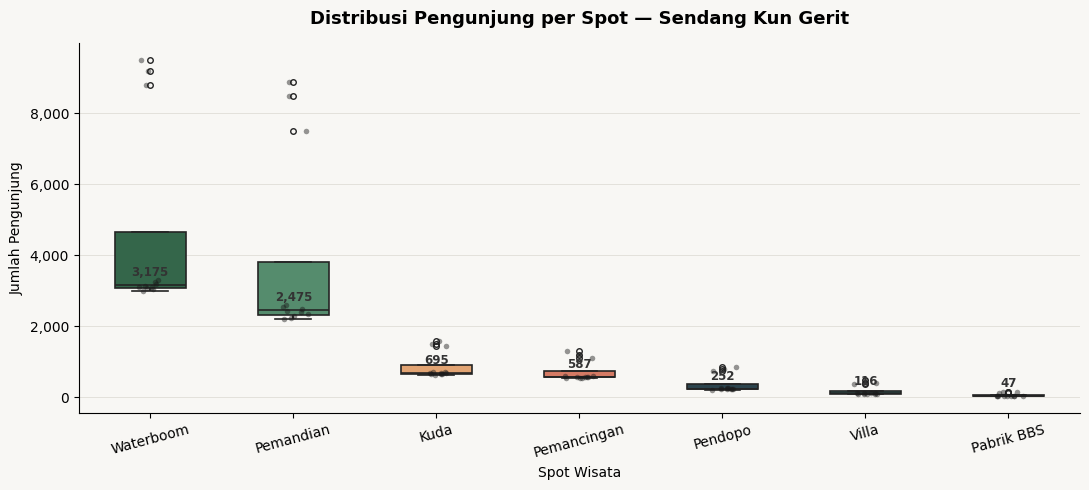

In [11]:
# ---Distribusi Pengunjung Per Spot
print("\n[EDA-1] Distribusi Pengunjung per Spot ...")
 
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#F8F7F4')
 
order_spots = (df.groupby('Nama_Spot')['Pengunjung']
               .median().sort_values(ascending=False).index.tolist())
 
sns.boxplot(data=df, x='Nama_Spot', y='Pengunjung',
            order=order_spots, palette=PALETTE_SPOT,
            width=0.5, linewidth=1.2, fliersize=4, ax=ax)
sns.stripplot(data=df, x='Nama_Spot', y='Pengunjung',
              order=order_spots, color='#1A1A1A',
              size=4, alpha=0.45, jitter=True, ax=ax)
 
ax.set_title('Distribusi Pengunjung per Spot — Sendang Kun Gerit',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Spot Wisata', fontsize=10)
ax.set_ylabel('Jumlah Pengunjung', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=15)
 
# Anotasi median
for i, spot in enumerate(order_spots):
    med = df[df['Nama_Spot'] == spot]['Pengunjung'].median()
    ax.text(i, med + 150, f'{int(med):,}',
            ha='center', va='bottom', fontsize=8.5,
            color='#333', fontweight='bold')
plt.tight_layout()


[EDA-2] Tren pengunjung per bulan ...


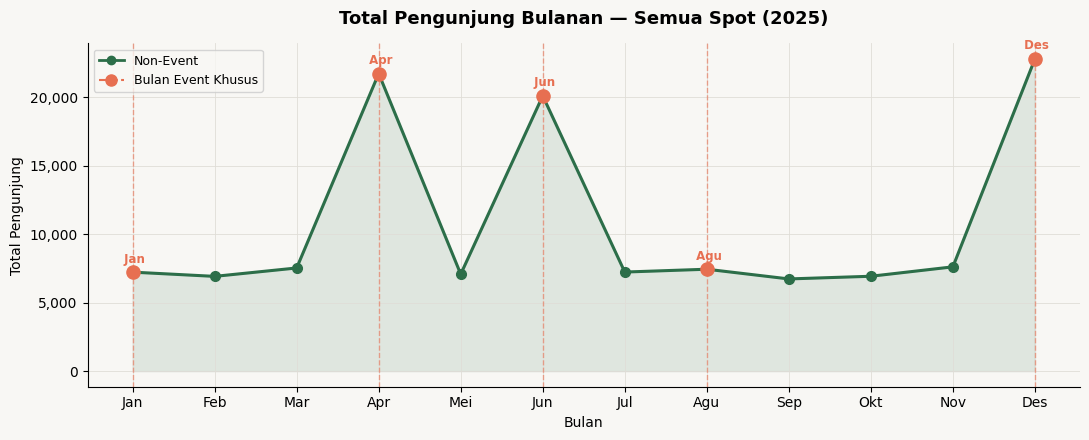

In [12]:
# ---Tren Bulanan
print("\n[EDA-2] Tren pengunjung per bulan ...")
 
bulanan = df.groupby('Bulan')['Pengunjung'].sum().reset_index()
bulanan['Nama_Bulan'] = bulanan['Bulan'].map(NAMA_BULAN)
event_bulan = df.groupby('Bulan')['Event_Khusus'].max().reset_index()
bulanan = bulanan.merge(event_bulan, on='Bulan')
 
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(bulanan['Bulan'], bulanan['Pengunjung'],
                alpha=0.12, color=COLOR_MAIN)
ax.plot(bulanan['Bulan'], bulanan['Pengunjung'],
        marker='o', color=COLOR_MAIN, lw=2.2, markersize=7)

# Tandai bulan event
for _, row in bulanan[bulanan['Event_Khusus'] == 1].iterrows():
    ax.axvline(x=row['Bulan'], color=COLOR_EVENT,
               linestyle='--', linewidth=1, alpha=0.6)
    ax.scatter(row['Bulan'], row['Pengunjung'],
               color=COLOR_EVENT, s=90, zorder=5)
    ax.text(row['Bulan'], row['Pengunjung'] + 700,
            f" {row['Nama_Bulan']}", ha='center',
            fontsize=8.5, color=COLOR_EVENT, fontweight='bold')
 
ax.set_xticks(range(1, 13))
ax.set_xticklabels([NAMA_BULAN[i] for i in range(1, 13)])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))
ax.set_title('Total Pengunjung Bulanan — Semua Spot (2025)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Bulan', fontsize=10)
ax.set_ylabel('Total Pengunjung', fontsize=10)
 
from matplotlib.lines import Line2D
legend_els = [
    Line2D([0], [0], color=COLOR_MAIN, lw=2, marker='o', label='Non-Event'),
    Line2D([0], [0], color=COLOR_EVENT, lw=1.5, linestyle='--',
           marker='o', markersize=8, label='Bulan Event Khusus'),
]
ax.legend(handles=legend_els, fontsize=9)
 
plt.tight_layout()


[EDA-3] Heatmap Spot × Bulan ...


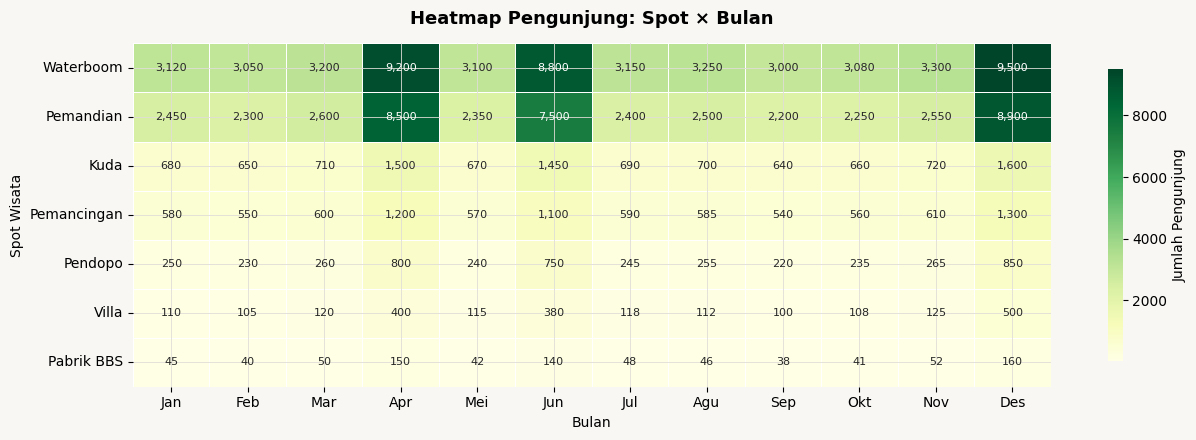

In [13]:
# ---Heatmap Pengunjung: Spot x bulan
print("\n[EDA-3] Heatmap Spot × Bulan ...")

pivot = df.pivot_table(values='Pengunjung',
                       index='Nama_Spot', columns='Bulan', aggfunc='sum')
pivot.columns = [NAMA_BULAN[c] for c in pivot.columns]
pivot = pivot.reindex(order_spots)
 
fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(pivot, annot=True, fmt=',d', cmap='YlGn',
            linewidths=0.4, linecolor='white',
            annot_kws={'size': 8}, ax=ax,
            cbar_kws={'label': 'Jumlah Pengunjung', 'shrink': 0.85})
ax.set_title('Heatmap Pengunjung: Spot × Bulan',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Bulan', fontsize=10)
ax.set_ylabel('Spot Wisata', fontsize=10)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
 
plt.tight_layout()


[EDA-4] Dampak event khusus per spot ...


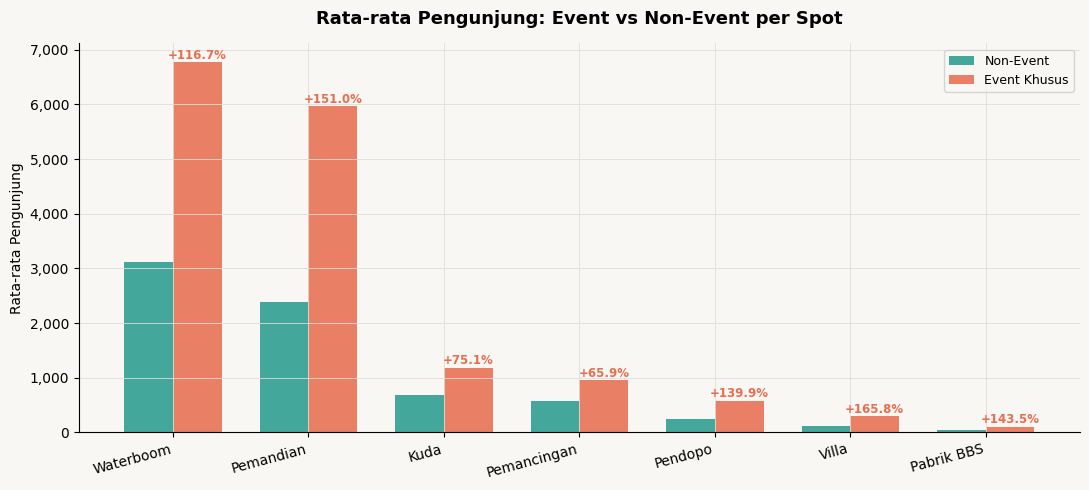

In [14]:
# ---Dampak Event atau Non-Event
print("\n[EDA-4] Dampak event khusus per spot ...")
 
event_df = df.groupby(['Nama_Spot', 'Event_Khusus'])['Pengunjung'] \
             .mean().reset_index()
event_df['Event_Label'] = event_df['Event_Khusus'].map(
    {0: 'Non-Event', 1: 'Event Khusus'})
 
# Hitung % kenaikan
pivot_ev = event_df.pivot(index='Nama_Spot',
                           columns='Event_Label',
                           values='Pengunjung').reindex(order_spots)
pivot_ev['Kenaikan (%)'] = ((pivot_ev['Event Khusus'] - pivot_ev['Non-Event'])
                             / pivot_ev['Non-Event'] * 100).round(1)
 
fig, ax = plt.subplots(figsize=(11, 5))
x   = np.arange(len(order_spots))
w   = 0.36
b1  = ax.bar(x - w/2, pivot_ev['Non-Event'], width=w,
             color=COLOR_NONEVENT, label='Non-Event', alpha=0.88)
b2  = ax.bar(x + w/2, pivot_ev['Event Khusus'], width=w,
             color=COLOR_EVENT, label='Event Khusus', alpha=0.88)
 
# Anotasi % kenaikan
for i, spot in enumerate(order_spots):
    pct = pivot_ev.loc[spot, 'Kenaikan (%)']
    top = pivot_ev.loc[spot, 'Event Khusus']
    ax.text(i + w/2, top + 60, f'+{pct}%',
            ha='center', fontsize=8.5, color=COLOR_EVENT, fontweight='bold')
 
ax.set_xticks(x)
ax.set_xticklabels(order_spots, rotation=15, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))
ax.set_title('Rata-rata Pengunjung: Event vs Non-Event per Spot',
             fontsize=13, fontweight='bold', pad=14)
ax.set_ylabel('Rata-rata Pengunjung', fontsize=10)
ax.legend(fontsize=9)
 
plt.tight_layout()


[EDA-5] Heatmap korelasi...


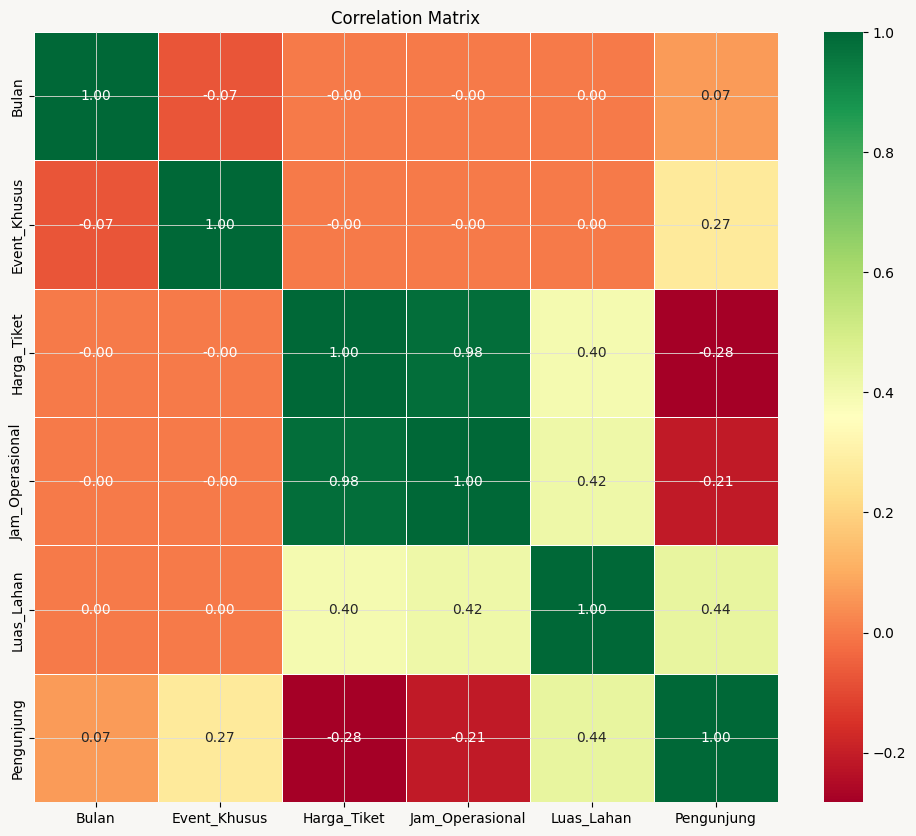

In [15]:
# ---Heatmap Korelasi
print("\n[EDA-5] Heatmap korelasi...")
# definisikan label berdasarkan type data
numeric_data = df.select_dtypes(include=['number']).columns
categoric_data = df.select_dtypes(include=['object']).columns

plt.figure(figsize=(12,10))
corr_matrix = df[numeric_data].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdYlGn', linewidths=.5)
plt.title("Correlation Matrix")
plt.show()

Note: Multikolinearitas di Jam_Operasional dan Harga_Tiket. Sebaiknya buat Feature baru atau drop salah satu dan biarkan Lasso yang mengeliminasi


[EDA-6] Scatter Harga Tiket vs Pengunjung ...


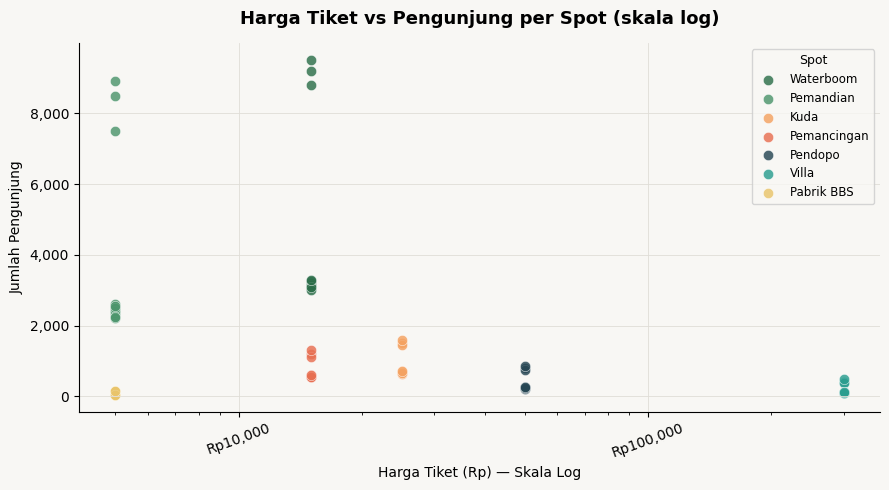

In [16]:
# ---Scatter Harga Tiket VS Pengunjung per Spot
print("\n[EDA-6] Scatter Harga Tiket vs Pengunjung ...")
 
fig, ax = plt.subplots(figsize=(9, 5))
for i, spot in enumerate(order_spots):
    sub = df[df['Nama_Spot'] == spot]
    ax.scatter(sub['Harga_Tiket'], sub['Pengunjung'],
               label=spot, color=PALETTE_SPOT[i],
               s=55, alpha=0.82, edgecolors='white', linewidths=0.4)
 
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'Rp{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))
ax.set_title('Harga Tiket vs Pengunjung per Spot (skala log)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Harga Tiket (Rp) — Skala Log', fontsize=10)
ax.set_ylabel('Jumlah Pengunjung', fontsize=10)
ax.legend(fontsize=8.5, title='Spot', title_fontsize=9,
          loc='upper right')
ax.tick_params(axis='x', rotation=20)
 
plt.tight_layout()

In [17]:
# =============================================================================
# RINGKASAN TEMUAN EDA (teks)
# =============================================================================
print("\n" + "=" * 60)
print("  RINGKASAN TEMUAN EDA")
print("=" * 60)
 
corr_target = df[numeric_data].corr()['Pengunjung'].drop('Pengunjung').abs()
corr_target = corr_target.sort_values(ascending=False)
 
print("\n  Korelasi fitur terhadap Pengunjung:")
for feat, val in corr_target.items():
    bar = '█' * int(val * 20)
    print(f"  {feat:<20} {val:.3f}  {bar}")
 
ev_ratio = (df[df['Event_Khusus']==1]['Pengunjung'].mean() /
            df[df['Event_Khusus']==0]['Pengunjung'].mean())
print(f"\n  Rata-rata pengunjung saat EVENT   : {df[df['Event_Khusus']==1]['Pengunjung'].mean():,.0f}")
print(f"  Rata-rata pengunjung non-EVENT    : {df[df['Event_Khusus']==0]['Pengunjung'].mean():,.0f}")
print(f"  Rasio Event/Non-Event             : {ev_ratio:.2f}× lebih ramai")
 
print(f"\n  Spot terpadat  : Waterboom (median {df[df['Nama_Spot']=='Waterboom']['Pengunjung'].median():,.0f})")
print(f"  Spot tersepi   : Pabrik BBS (median {df[df['Nama_Spot']=='Pabrik BBS']['Pengunjung'].median():,.0f})")
print(f"  Bulan puncak   : {df.groupby('Bulan')['Pengunjung'].sum().idxmax()} "
      f"({NAMA_BULAN[df.groupby('Bulan')['Pengunjung'].sum().idxmax()]}) "
      f"— {df.groupby('Bulan')['Pengunjung'].sum().max():,} pengunjung")
print(f"  Bulan terendah : {df.groupby('Bulan')['Pengunjung'].sum().idxmin()} "
      f"({NAMA_BULAN[df.groupby('Bulan')['Pengunjung'].sum().idxmin()]}) "
      f"— {df.groupby('Bulan')['Pengunjung'].sum().min():,} pengunjung")


  RINGKASAN TEMUAN EDA

  Korelasi fitur terhadap Pengunjung:
  Luas_Lahan           0.435  ████████
  Harga_Tiket          0.282  █████
  Event_Khusus         0.274  █████
  Jam_Operasional      0.209  ████
  Bulan                0.066  █

  Rata-rata pengunjung saat EVENT   : 2,268
  Rata-rata pengunjung non-EVENT    : 1,022
  Rasio Event/Non-Event             : 2.22× lebih ramai

  Spot terpadat  : Waterboom (median 3,175)
  Spot tersepi   : Pabrik BBS (median 47)
  Bulan puncak   : 12 (Des) — 22,810 pengunjung
  Bulan terendah : 9 (Sep) — 6,738 pengunjung


Note: Dikarenakan terdapat Skew data yang tinggi pada Fitur Pengunjung, Harga Tiket, dan Jam Operasional. Sebaiknya lakukan Log Transform untuk meningkatkan linearitas

#### Pre-Processing Data

In [18]:
# ---Feature Engineering (Buat Fitur Baru)
''' 
Fitur Tiket_X_Jam untuk mengetahui seberapa berpengaruh lamanya jam operasional dengan harga tiket
Fitur Harga_per_Luas untuk mengetahui seberapa premium tempat tersebut
'''
df['Tiket_x_Jam'] = df['Harga_Tiket'] * df['Jam_Operasional']
df['Harga_per_Luas'] = df['Harga_Tiket'] / df['Luas_Lahan']

In [19]:
df.describe()

,Bulan,Event_Khusus,Harga_Tiket,Jam_Operasional,Luas_Lahan,Pengunjung,Tiket_x_Jam,Harga_per_Luas
count,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,8.400000e+01,84.000000
mean,6.500000,0.416667,59285.714286,11.714286,3828.571429,1541.071429,1.198571e+06,15.532524
std,3.472786,0.495968,99894.953432,5.205584,2476.908850,2257.297066,2.471030e+06,16.322681
min,1.000000,0.000000,5000.000000,8.000000,1000.000000,38.000000,4.000000e+04,0.684932
25%,3.750000,0.000000,5000.000000,8.000000,1000.000000,205.000000,5.000000e+04,3.000000
50%,6.500000,0.000000,15000.000000,10.000000,4500.000000,625.000000,1.500000e+05,5.555556
75%,9.250000,1.000000,50000.000000,12.000000,6500.000000,2312.500000,6.000000e+05,33.333333
max,12.000000,1.000000,300000.000000,24.000000,7300.000000,9500.000000,7.200000e+06,46.153846


In [20]:
# ---Ordinal Encoding untuk Fitur Ordinal (Aksesibilitas)
ORDINAL_MAP = {'Mudah': 0, 'Sedang': 1, 'Sukar': 2}
df['Aksesibilitas_enc'] = df['Aksesibilitas'].map(ORDINAL_MAP)

print(f"\n  Aksesibilitas → Aksesibilitas_enc")
for k, v in ORDINAL_MAP.items():
    print(f"    {k:<8} → {v}")


  Aksesibilitas → Aksesibilitas_enc
    Mudah    → 0
    Sedang   → 1
    Sukar    → 2


In [21]:
# ---Label Encoding untuk Fitur Nominal (Nama_Spot)
le_spot = LabelEncoder()
df['Nama_Spot_enc'] = le_spot.fit_transform(df['Nama_Spot'])
spot_mapping = dict(zip(le_spot.classes_,
                        le_spot.transform(le_spot.classes_)))

print(f"\n  Nama_Spot → Nama_Spot_enc")
for spot, code in sorted(spot_mapping.items(), key=lambda x: x[1]):
    print(f"    {spot:<15} → {code}")
 
# Simpan LabelEncoder spot untuk deployment nanti
joblib.dump(le_spot, 'le_spot.pkl')
print(f"\n  LabelEncoder spot tersimpan: le_spot.pkl")


  Nama_Spot → Nama_Spot_enc
    Kuda            → 0
    Pabrik BBS      → 1
    Pemancingan     → 2
    Pemandian       → 3
    Pendopo         → 4
    Villa           → 5
    Waterboom       → 6

  LabelEncoder spot tersimpan: le_spot.pkl


In [22]:
df.head()

,Nama_Spot,Bulan,Event_Khusus,Harga_Tiket,Jam_Operasional,Aksesibilitas,Luas_Lahan,Pengunjung,Nama_Bulan,Tiket_x_Jam,Harga_per_Luas,Aksesibilitas_enc,Nama_Spot_enc
0,Pemandian,1,1,5000,10,Mudah,7300,2450,Jan,50000,0.684932,0,3
1,Waterboom,1,1,15000,10,Sedang,5000,3120,Jan,150000,3.000000,1,6
2,Kuda,1,1,25000,8,Sedang,4500,680,Jan,200000,5.555556,1,0
3,Villa,1,1,300000,24,Sukar,6500,110,Jan,7200000,46.153846,2,5
4,Pendopo,1,1,50000,12,Mudah,1500,250,Jan,600000,33.333333,0,4


In [23]:
# ---Log Transform
df['Pengunjung_Log'] = np.log1p(df['Pengunjung'])
df['Harga_Tiket_Log'] = np.log1p(df['Harga_Tiket'])
df['Harga_per_Luas_Log'] = np.log1p(df['Harga_per_Luas'])

# Cek kembali distribusinya
print(f"Skewness sebelum: {df['Pengunjung'].skew()}")
print(f"Skewness sesudah Log Trans: {df['Pengunjung_Log'].skew()}\n")
print(f"Skewness sebelum: {df['Harga_Tiket'].skew()}")
print(f"Skewness sesudah Log Trans: {df['Harga_Tiket_Log'].skew()}\n")
print(f"Skewness sebelum: {df['Harga_per_Luas'].skew()}")
print(f"Skewness sesudah Log Trans: {df['Harga_per_Luas_Log'].skew()}")

Skewness sebelum: 2.3850408414108832
Skewness sesudah Log Trans: -0.06472182647639432

Skewness sebelum: 1.992805241514632
Skewness sesudah Log Trans: 0.8002379109598363

Skewness sebelum: 0.917804279514012
Skewness sesudah Log Trans: 0.050154926711790115


In [24]:
df.head()

,Nama_Spot,Bulan,Event_Khusus,Harga_Tiket,Jam_Operasional,Aksesibilitas,Luas_Lahan,Pengunjung,Nama_Bulan,Tiket_x_Jam,Harga_per_Luas,Aksesibilitas_enc,Nama_Spot_enc,Pengunjung_Log,Harga_Tiket_Log,Harga_per_Luas_Log
0,Pemandian,1,1,5000,10,Mudah,7300,2450,Jan,50000,0.684932,0,3,7.804251,8.517393,0.521725
1,Waterboom,1,1,15000,10,Sedang,5000,3120,Jan,150000,3.000000,1,6,8.045909,9.615872,1.386294
2,Kuda,1,1,25000,8,Sedang,4500,680,Jan,200000,5.555556,1,0,6.523562,10.126671,1.880313
3,Villa,1,1,300000,24,Sukar,6500,110,Jan,7200000,46.153846,2,5,4.709530,12.611541,3.853416
4,Pendopo,1,1,50000,12,Mudah,1500,250,Jan,600000,33.333333,0,4,5.525453,10.819798,3.536117


In [25]:
# --- Splitting Data ke Train dan Test
FITUR = [
    'Nama_Spot_enc',     # identitas spot (encoded)
    'Bulan',             # bulan ke-1 s.d. 12
    'Event_Khusus',      # 0 = tidak ada event, 1 = ada event
    'Harga_Tiket_Log',   # harga tiket setelah di Log Trans
    'Aksesibilitas_enc', # 0=Mudah, 1=Sedang, 2=Sukar (encoded ordinal)
    'Luas_Lahan',        # luas lahan dalam m²
    'Tiket_x_Jam',
    # 'Harga_per_Luas_Log'
]
TARGET = 'Pengunjung_Log'

X = df[FITUR]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    shuffle      = False
)
 
print(f"  Total data  : {len(df)} baris")
print(f"  Train       : {len(X_train)} baris ({len(X_train)/len(df)*100:.0f}%)")
print(f"  Test        : {len(X_test)} baris  ({len(X_test)/len(df)*100:.0f}%)")

  Total data  : 84 baris
  Train       : 58 baris (69%)
  Test        : 26 baris  (31%)


In [26]:
# --- Cek Distribusi Spot di Train dan Test
train_spot_dist = (
    df.loc[X_train.index, 'Nama_Spot']
    .value_counts().sort_index()
)
test_spot_dist = (
    df.loc[X_test.index, 'Nama_Spot']
    .value_counts().sort_index()
)
print(f"\n  Distribusi spot di Train:")
for spot, n in train_spot_dist.items():
    print(f"    {spot:<15} : {n} baris")
print(f"\n  Distribusi spot di Test:")
for spot, n in test_spot_dist.items():
    print(f"    {spot:<15} : {n} baris")


  Distribusi spot di Train:
    Kuda            : 8 baris
    Pabrik BBS      : 8 baris
    Pemancingan     : 8 baris
    Pemandian       : 9 baris
    Pendopo         : 8 baris
    Villa           : 8 baris
    Waterboom       : 9 baris

  Distribusi spot di Test:
    Kuda            : 4 baris
    Pabrik BBS      : 4 baris
    Pemancingan     : 4 baris
    Pemandian       : 3 baris
    Pendopo         : 4 baris
    Villa           : 4 baris
    Waterboom       : 3 baris


In [27]:
# --- Scalling
scaler = StandardScaler()

# Fit ke train dan transform ke test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Ubah kembali ke DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled,
                               columns=FITUR, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,
                               columns=FITUR, index=X_test.index)

print(f"\n  Statistik X_train SEBELUM scaling:")
print(df[FITUR].describe().loc[['mean','std','min','max']].round(2).to_string())
 
print(f"\n  Statistik X_train SESUDAH scaling (mean≈0, std≈1):")
print(X_train_scaled.describe().loc[['mean','std','min','max']].round(3).to_string())
 
# Simpan scaler untuk deployment
joblib.dump(scaler, 'scaler.pkl')
print(f"\n  StandardScaler tersimpan: scaler.pkl")


  Statistik X_train SEBELUM scaling:
      Nama_Spot_enc  Bulan  Event_Khusus  Harga_Tiket_Log  Aksesibilitas_enc  Luas_Lahan  Tiket_x_Jam
mean           3.00   6.50          0.42             9.97               1.14     3828.57   1198571.43
std            2.01   3.47          0.50             1.33               0.84     2476.91   2471029.80
min            0.00   1.00          0.00             8.52               0.00     1000.00     40000.00
max            6.00  12.00          1.00            12.61               2.00     7300.00   7200000.00

  Statistik X_train SESUDAH scaling (mean≈0, std≈1):
      Nama_Spot_enc  Bulan  Event_Khusus  Harga_Tiket_Log  Aksesibilitas_enc  Luas_Lahan  Tiket_x_Jam
mean         -0.000  0.000        -0.000           -0.000              0.000      -0.000        0.000
std           1.009  1.009         1.009            1.009              1.009       1.009        1.009
min          -1.523 -1.525        -0.966           -1.087             -1.347      -1.180    

In [28]:
# ---Simpan versi CSV untuk keperluan analisis lanjutan
X_train_scaled.assign(Pengunjung=y_train).to_csv('train_scaled.csv', index=False)
X_test_scaled.assign(Pengunjung=y_test).to_csv('test_scaled.csv', index=False)

In [29]:
# ---Simpan joblib untuk pipeline model
joblib.dump((X_train_scaled, X_test_scaled, y_train, y_test),'data_split.pkl')

['data_split.pkl']

In [30]:
print(f"  train_scaled.csv   → {len(X_train_scaled)} baris")
print(f"  test_scaled.csv    → {len(X_test_scaled)} baris")
print(f"  data_split.pkl     → (X_train, X_test, y_train, y_test)")

  train_scaled.csv   → 58 baris
  test_scaled.csv    → 26 baris
  data_split.pkl     → (X_train, X_test, y_train, y_test)


#### Modelling

In [31]:
# ---Set Kebutuhan
FITUR = ['Nama_Spot_enc', 'Bulan', 'Event_Khusus', 'Harga_Tiket_Log',
         'Aksesibilitas_enc', 'Luas_Lahan', 'Tiket_x_Jam']
FITUR_LABEL = ['Nama_Spot', 'Bulan', 'Event_Khusus', 'Harga_Tiket',
               'Aksesibilitas', 'Luas_Lahan', 'Tiket_x_Jam']

In [32]:
# ---Load Data Hasil Split
X_train, X_test, y_train, y_test = joblib.load('data_split.pkl')
 
print(f"  X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"  X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
 
# Gabungkan untuk KFold CV penuh
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])

  X_train : (58, 7)  |  y_train : (58,)
  X_test  : (26, 7)   |  y_test  : (26,)


In [33]:
# ---Train Model Baseline
baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)
 
mae_base  = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base   = r2_score(y_test, y_pred_base)
 
print(f"  Baseline MAE  : {mae_base:,.2f}")
print(f"  Baseline RMSE : {rmse_base:,.2f}")
print(f"  Baseline R²   : {r2_base:.2f}")

  Baseline MAE  : 0.43
  Baseline RMSE : 0.54
  Baseline R²   : 0.87


In [34]:
# ---Tuning Alpha dengan LassoCV dan K-Fold untuk mendapatkan Alpha terbaik
alphas_grid = np.logspace(-4, 3, 200)   # 200 nilai dari 0.0001 s.d. 1000
 
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
 
lasso_cv = LassoCV(
    alphas      = alphas_grid,
    cv          = kf,
    max_iter    = 10000,
    random_state= RANDOM_STATE,
    n_jobs      = -1
)
lasso_cv.fit(X_train, y_train)
 
alpha_optimal = lasso_cv.alpha_
print(f"  Alpha optimal ditemukan : {alpha_optimal:.6f}")
print(f"  Rentang alpha diuji     : {alphas_grid.min():.4f} - {alphas_grid.max():.1f}")
print(f"  Jumlah fold CV          : {CV_FOLDS}")

  Alpha optimal ditemukan : 0.007934
  Rentang alpha diuji     : 0.0001 - 1000.0
  Jumlah fold CV          : 5


In [35]:
# ---Train Model Lasso dengan Alpha Optimal
lasso = Lasso(
    alpha      = alpha_optimal,
    max_iter   = 10000,
    random_state=RANDOM_STATE
)
lasso.fit(X_train, y_train)
 
print(f"  Model Lasso berhasil dilatih.")
print(f"  Intercept (β₀) : {lasso.intercept_:,.4f}")
 
# Koefisien tiap fitur
coef_df = pd.DataFrame({
    'Fitur'      : FITUR_LABEL,
    'Koefisien'  : lasso.coef_,
    'Abs_Coef'   : np.abs(lasso.coef_),
    'Status'     : ['Aktif ✓' if c != 0 else 'Di-nolkan ✗' for c in lasso.coef_]
}).sort_values('Abs_Coef', ascending=False)
 
print(f"\n  Koefisien fitur (L1 Lasso):")
print(f"  {'Fitur':<20} {'Koefisien':>14}  Status")
print(f"  {'-'*50}")
for _, row in coef_df.iterrows():
    print(f"  {row['Fitur']:<20} {row['Koefisien']:>14.4f}  {row['Status']}")
 
n_active  = (lasso.coef_ != 0).sum()
n_zeroed  = (lasso.coef_ == 0).sum()
print(f"\n  Fitur aktif (coef ≠ 0) : {n_active}")
print(f"  Fitur di-nolkan Lasso  : {n_zeroed}")

  Model Lasso berhasil dilatih.
  Intercept (β₀) : 6.4259

  Koefisien fitur (L1 Lasso):
  Fitur                     Koefisien  Status
  --------------------------------------------------
  Tiket_x_Jam                 -2.2716  Aktif ✓
  Luas_Lahan                   1.3894  Aktif ✓
  Harga_Tiket                  0.9161  Aktif ✓
  Nama_Spot                    0.5429  Aktif ✓
  Aksesibilitas                0.4180  Aktif ✓
  Event_Khusus                 0.2549  Aktif ✓
  Bulan                        0.0209  Aktif ✓

  Fitur aktif (coef ≠ 0) : 7
  Fitur di-nolkan Lasso  : 0


In [36]:
# ---Prediksi dan Evaluasi Final Pada Data Test
y_pred = lasso.predict(X_test)
 
# Bulatkan ke bilangan bulat (jumlah pengunjung tidak bisa desimal)
y_pred_rounded = np.round(y_pred).astype(int)
y_pred_rounded = np.clip(y_pred_rounded, 0, None)   # tidak boleh negatif
 
mae_lasso  = mean_absolute_error(y_test, y_pred)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lasso   = r2_score(y_test, y_pred)
 
print(f"\n  ┌─────────────────────────────────────────────┐")
print(f"  │       HASIL EVALUASI MODEL LASSO             │")
print(f"  ├──────────────────┬──────────────┬────────────┤")
print(f"  │ Metrik           │   Baseline   │   Lasso    │")
print(f"  ├──────────────────┼──────────────┼────────────┤")
print(f"  │ MAE              │ {mae_base:>10,.2f}   │ {mae_lasso:>8,.2f}   │")
print(f"  │ RMSE             │ {rmse_base:>10,.2f}   │ {rmse_lasso:>8,.2f}   │")
print(f"  │ R² Score         │ {r2_base:>10.4f}   │ {r2_lasso:>8.4f}   │")
print(f"  └──────────────────┴──────────────┴────────────┘")


  ┌─────────────────────────────────────────────┐
  │       HASIL EVALUASI MODEL LASSO             │
  ├──────────────────┬──────────────┬────────────┤
  │ Metrik           │   Baseline   │   Lasso    │
  ├──────────────────┼──────────────┼────────────┤
  │ MAE              │       0.43   │     0.44   │
  │ RMSE             │       0.54   │     0.55   │
  │ R² Score         │     0.8724   │   0.8648   │
  └──────────────────┴──────────────┴────────────┘


In [37]:
print("Hasil Evaluasi Model Linear Regression-L1: ")
print(f"Mean Absolut Error: {mae_lasso:.2f}")
print(f"Root Mean Squared Error: {rmse_lasso:.2f}")
print(f"R2: {r2_lasso:.2f}")

Hasil Evaluasi Model Linear Regression-L1: 
Mean Absolut Error: 0.44
Root Mean Squared Error: 0.55
R2: 0.86


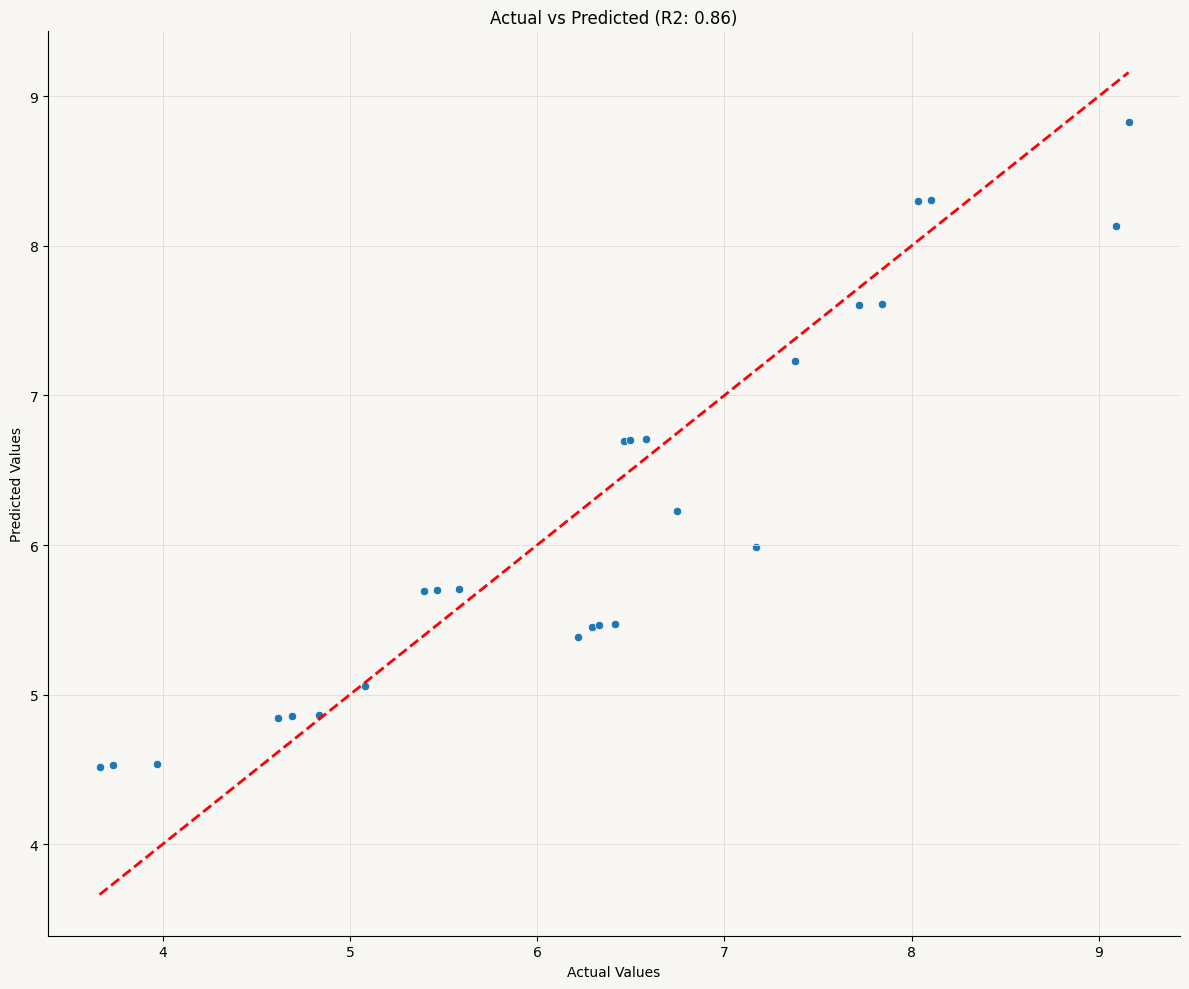

In [38]:
# ---Plot Residual
# 1. Hitung Residual
residuals = y_test - y_pred

# 2. Buat Dashboard Evaluasi
plt.figure(figsize=(12, 10))

# Plot: Actual vs Predicted (Melihat linearitas)
sns.scatterplot(x=y_test, y=y_pred, alpha=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Actual vs Predicted (R2: {r2_score(y_test, y_pred):.2f})')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.tight_layout()
plt.show()

In [39]:
# Jalankan Cross-Validation (Misal 5-Fold)
kf = KFold(n_splits=5, shuffle=False)
scores = cross_val_score(lasso, X_train, y_train, cv=kf, scoring='r2')

print(f"R2 Scores tiap fold: {scores}")
print(f"R2 Mean: {scores.mean():.4f}")
print(f"R2 Std Dev: {scores.std():.4f}")

R2 Scores tiap fold: [0.46729805 0.87516562 0.77403204 0.84476447 0.53333167]
R2 Mean: 0.6989
R2 Std Dev: 0.1668


In [40]:
# Jalankan Cross-Validation (Misal 10-Fold)
kf2 = KFold(n_splits=10, shuffle=False)
scores = cross_val_score(lasso, X_test, y_test, cv=kf2, scoring='r2')

print(f"R2 Scores tiap fold: {scores}")
print(f"R2 Mean: {scores.mean():.4f}")
print(f"R2 Std Dev: {scores.std():.4f}")

R2 Scores tiap fold: [ 0.87286689  0.81433544  0.9525428   0.58442838  0.69877844 -0.01431061
  0.90635125  0.45125274 -0.08890738  0.70151932]
R2 Mean: 0.5879
R2 Std Dev: 0.3509


### **Save Model**

In [42]:
joblib.dump(lasso, "lasso_model.pkl")

['lasso_model.pkl']